In [6]:
import pandas as pd

matches = pd.read_csv('matches.csv.csv')
deliveries = pd.read_csv('deliveries.csv.csv')

print("Matches:", matches.shape)
print("Deliveries:", deliveries.shape)

Matches: (1095, 20)
Deliveries: (260920, 17)


In [7]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [8]:
print(matches.columns.tolist())

['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']


In [9]:
print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [10]:
print("Total matches:", len(matches))
print("Seasons:", sorted(matches['season'].unique()))
print("Total teams:", matches['team1'].nunique())
print("Total cities:", matches['city'].nunique())

Total matches: 1095
Seasons: ['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024']
Total teams: 19
Total cities: 36


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded!")

All libraries loaded!


winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


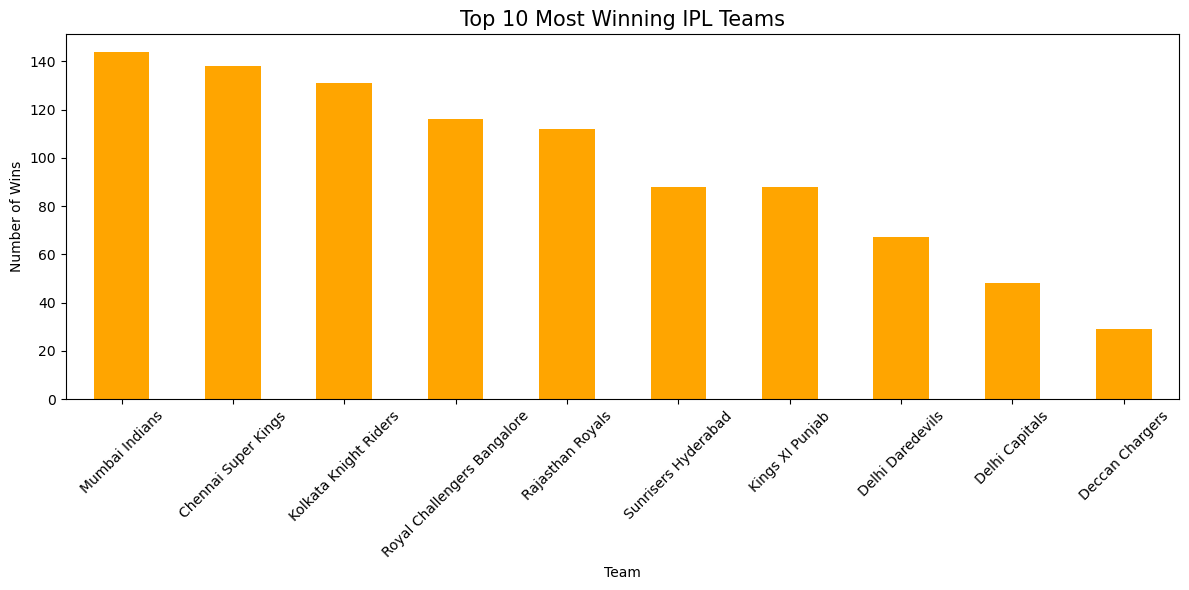

In [13]:
top_teams = matches['winner'].value_counts().head(10)
print(top_teams)

plt.figure(figsize=(12,6))
top_teams.plot(kind='bar', color='orange')
plt.title('Top 10 Most Winning IPL Teams', fontsize=15)
plt.xlabel('Team')
plt.ylabel('Number of Wins')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_teams.png')
plt.show()

Toss winner wins the match: 50.6% of times


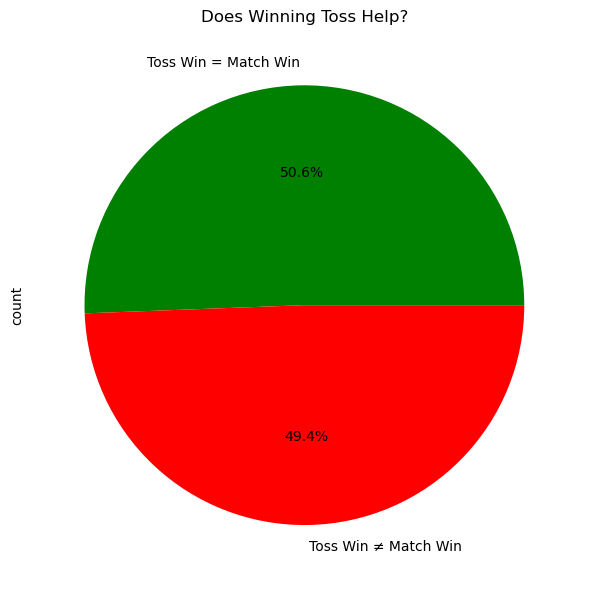

In [14]:
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']

toss_impact = matches['toss_win_match_win'].value_counts()
percentage = matches['toss_win_match_win'].mean() * 100

print(f"Toss winner wins the match: {percentage:.1f}% of times")

plt.figure(figsize=(6,6))
toss_impact.plot(kind='pie', 
                 labels=['Toss Win = Match Win', 'Toss Win ≠ Match Win'],
                 autopct='%1.1f%%',
                 colors=['green','red'])
plt.title('Does Winning Toss Help?')
plt.tight_layout()
plt.savefig('toss_impact.png')
plt.show()

toss_decision
field    704
bat      391
Name: count, dtype: int64


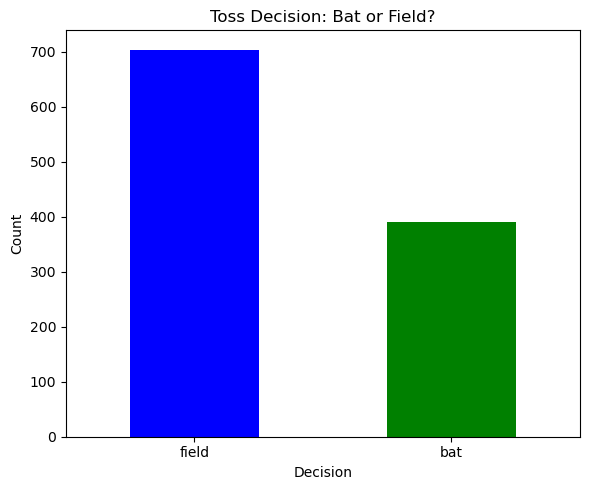

In [15]:
toss_decision = matches['toss_decision'].value_counts()
print(toss_decision)
plt.figure(figsize=(6,5))
toss_decision.plot(kind='bar', color=['blue','green'])
plt.title('Toss Decision: Bat or Field?')
plt.xlabel('Decision')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('toss_decision.png')
plt.show()

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


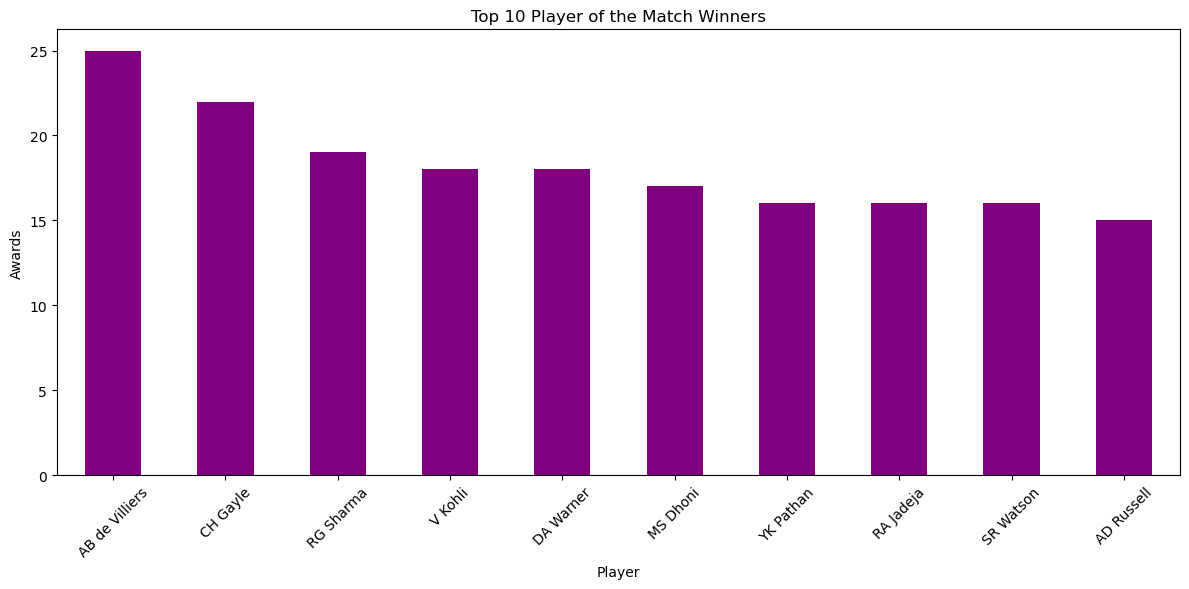

In [16]:
top_players = matches['player_of_match'].value_counts().head(10)
print(top_players)
plt.figure(figsize=(12,6))
top_players.plot(kind='bar', color='purple')
plt.title('Top 10 Player of the Match Winners')
plt.xlabel('Player')
plt.ylabel('Awards')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_players.png')
plt.show()

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches.csv.csv')
deliveries = pd.read_csv('deliveries.csv.csv')

print("Ready:", matches.shape)

Ready: (1095, 20)


Win rate when choosing to FIELD: 53.6%
Win rate when choosing to BAT: 45.3%


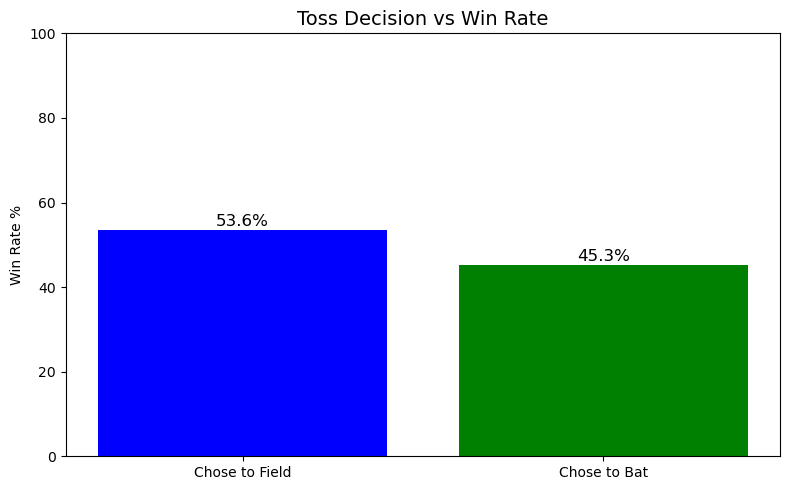

In [5]:
field_df = matches[matches['toss_decision'] == 'field']
bat_df = matches[matches['toss_decision'] == 'bat']

field_win_rate = (field_df['toss_winner'] == field_df['winner']).mean() * 100
bat_win_rate = (bat_df['toss_winner'] == bat_df['winner']).mean() * 100

print(f"Win rate when choosing to FIELD: {field_win_rate:.1f}%")
print(f"Win rate when choosing to BAT: {bat_win_rate:.1f}%")

plt.figure(figsize=(8,5))
plt.bar(['Chose to Field', 'Chose to Bat'], 
        [field_win_rate, bat_win_rate],
        color=['blue', 'green'])
plt.title('Toss Decision vs Win Rate', fontsize=14)
plt.ylabel('Win Rate %')
plt.ylim(0, 100)
for i, v in enumerate([field_win_rate, bat_win_rate]):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('toss_decision_winrate.png')
plt.show()

In [6]:
season_winners = matches.groupby('season')['winner'].agg(lambda x: x.value_counts().index[0])
print("Season Champions:")
print(season_winners)

Season Champions:
season
2007/08         Rajasthan Royals
2009            Delhi Daredevils
2009/10           Mumbai Indians
2011         Chennai Super Kings
2012       Kolkata Knight Riders
2013              Mumbai Indians
2014             Kings XI Punjab
2015         Chennai Super Kings
2016         Sunrisers Hyderabad
2017              Mumbai Indians
2018         Chennai Super Kings
2019              Mumbai Indians
2020/21           Mumbai Indians
2021         Chennai Super Kings
2022              Gujarat Titans
2023              Gujarat Titans
2024       Kolkata Knight Riders
Name: winner, dtype: object


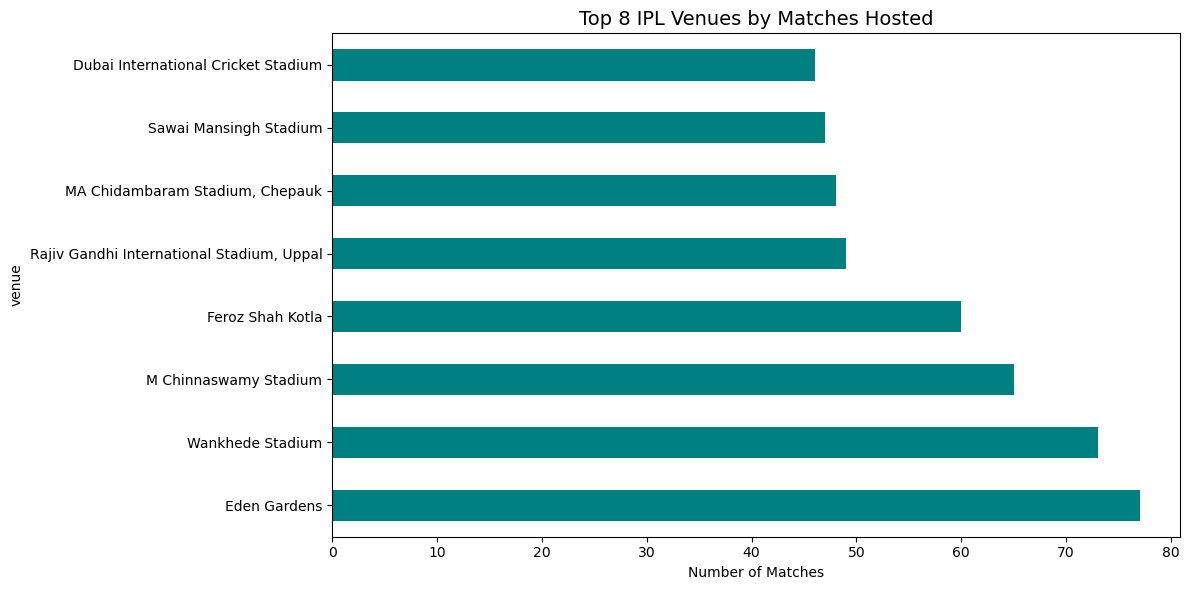

In [7]:
top_venues = matches['venue'].value_counts().head(8)
plt.figure(figsize=(12,6))
top_venues.plot(kind='barh', color='teal')
plt.title('Top 8 IPL Venues by Matches Hosted', fontsize=14)
plt.xlabel('Number of Matches')
plt.tight_layout()
plt.savefig('top_venues.png')
plt.show()

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

matches = pd.read_csv('matches.csv.csv')
deliveries = pd.read_csv('deliveries.csv.csv')

print("Ready:", matches.shape)

Ready: (1095, 20)


In [4]:
df_model = matches[['team1', 'team2', 'city', 'toss_winner', 
                     'toss_decision', 'winner']].dropna()

print("Rows available for training:", len(df_model))

Rows available for training: 1039


In [5]:
df_encoded = df_model.copy()
le_dict = {}

for col in ['team1', 'team2', 'city', 'toss_winner', 'toss_decision', 'winner']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    le_dict[col] = le

print("Encoding done!")
print(df_encoded.head())

Encoding done!
   team1  team2  city  toss_winner  toss_decision  winner
0     16      8     2           16              1       8
1      6      0     7            0              0       0
2      3     13    10           13              0       3
3     10     16    26           10              0      16
4      8      1    23            1              0       8


In [6]:
X = df_encoded[['team1', 'team2', 'city', 'toss_winner', 'toss_decision']]
y = df_encoded['winner']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 50.96%


In [7]:
team_wins = matches['winner'].value_counts()
team_matches = matches['team1'].value_counts() + matches['team2'].value_counts()
team_winrate = (team_wins / team_matches).fillna(0)


df_model2 = df_model.copy()
df_model2['team1_winrate'] = df_model2['team1'].map(
    lambda x: team_winrate.get(x, 0)
)
df_model2['team2_winrate'] = df_model2['team2'].map(
    lambda x: team_winrate.get(x, 0)
)

print(df_model2[['team1', 'team2', 'team1_winrate', 'team2_winrate']].head())

                         team1                        team2  team1_winrate  \
0  Royal Challengers Bangalore        Kolkata Knight Riders       0.483333   
1              Kings XI Punjab          Chennai Super Kings       0.463158   
2             Delhi Daredevils             Rajasthan Royals       0.416149   
3               Mumbai Indians  Royal Challengers Bangalore       0.551724   
4        Kolkata Knight Riders              Deccan Chargers       0.521912   

   team2_winrate  
0       0.521912  
1       0.579832  
2       0.506787  
3       0.483333  
4       0.386667  


In [8]:
df_encoded2 = df_model2.copy()

for col in ['team1', 'team2', 'city', 'toss_winner', 'toss_decision', 'winner']:
    le = LabelEncoder()
    df_encoded2[col] = le.fit_transform(df_encoded2[col].astype(str))

X2 = df_encoded2[['team1', 'team2', 'city', 'toss_winner', 
                   'toss_decision', 'team1_winrate', 'team2_winrate']]
y2 = df_encoded2['winner']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = RandomForestClassifier(n_estimators=200, random_state=42)
model2.fit(X_train2, y_train2)

accuracy2 = accuracy_score(y_test2, model2.predict(X_test2))
print(f"Improved Model Accuracy: {accuracy2:.2%}")

Improved Model Accuracy: 52.40%


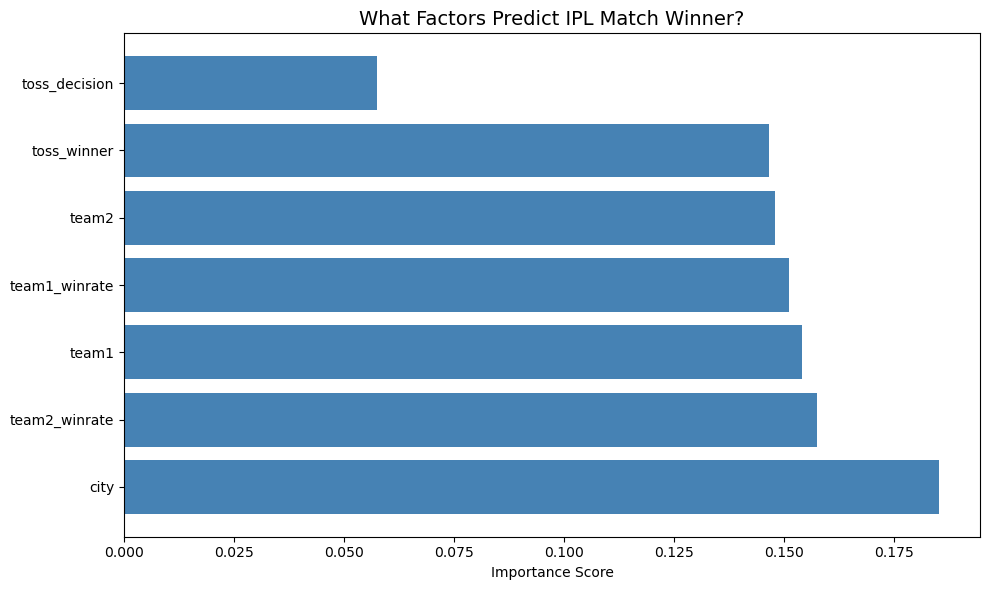

         feature  importance
2           city    0.185266
6  team2_winrate    0.157591
0          team1    0.154029
5  team1_winrate    0.151136
1          team2    0.147850
3    toss_winner    0.146587
4  toss_decision    0.057541


In [9]:
feature_names = ['team1', 'team2', 'city', 'toss_winner', 
                 'toss_decision', 'team1_winrate', 'team2_winrate']

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.title('What Factors Predict IPL Match Winner?', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print(importance_df)

In [10]:
print("=" * 50)
print("KEY FINDINGS FROM IPL ANALYSIS (2008-2024)")
print("=" * 50)
print(f"""
1. TEAM PERFORMANCE
   - Mumbai Indians are the most successful team (144 wins)
   - Chennai Super Kings second (138 wins)
   
2. TOSS IMPACT
   - Toss winner wins only 50.6% of matches
   - Toss is almost meaningless alone
   - BUT choosing to field after toss wins 53.6% vs 45.3% for batting
   
3. VENUE IS KING
   - City is the #1 predictor of match outcome
   - More important than team strength itself
   - Eden Gardens hosts most matches (77)
   
4. TOSS DECISION
   - 700+ teams chose to field vs 390 chose to bat
   - Captains strongly prefer chasing
   - Data proves they are right
   
5. MODEL PERFORMANCE
   - Random Forest Accuracy: 52.40%
   - Cricket is inherently unpredictable
   - Venue + team win rate are strongest predictors
""")
print("=" * 50)

KEY FINDINGS FROM IPL ANALYSIS (2008-2024)

1. TEAM PERFORMANCE
   - Mumbai Indians are the most successful team (144 wins)
   - Chennai Super Kings second (138 wins)
   
2. TOSS IMPACT
   - Toss winner wins only 50.6% of matches
   - Toss is almost meaningless alone
   - BUT choosing to field after toss wins 53.6% vs 45.3% for batting
   
3. VENUE IS KING
   - City is the #1 predictor of match outcome
   - More important than team strength itself
   - Eden Gardens hosts most matches (77)
   
4. TOSS DECISION
   - 700+ teams chose to field vs 390 chose to bat
   - Captains strongly prefer chasing
   - Data proves they are right
   
5. MODEL PERFORMANCE
   - Random Forest Accuracy: 52.40%
   - Cricket is inherently unpredictable
   - Venue + team win rate are strongest predictors



In [13]:
readme = """# IPL Match Winner Predictor & Analysis (2008-2024)

## Problem Statement
Can we predict the winner of an IPL match using historical data?
What factors actually determine who wins - teams, venue, or toss?

## Key Findings
- Mumbai Indians are the most successful team with 144 wins
- Toss barely matters - toss winner wins only 50.6% of matches
- Venue is the #1 predictor of match outcome - more important than team strength
- Teams choosing to field win 53.6% vs 45.3% when batting
- AB de Villiers leads Player of the Match awards with 25

## Machine Learning Model
- Algorithm: Random Forest Classifier
- Features: Team, City, Toss Winner, Toss Decision, Team Win Rate
- Accuracy: 52.40%
- Key insight: City/venue is the strongest predictor (importance: 0.185)

## Tech Stack
Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Jupyter Notebook

## Dataset
IPL matches data 2008-2024 - 1095 matches, 260920 ball-by-ball deliveries

## How to Run
pip install pandas numpy matplotlib seaborn scikit-learn
jupyter notebook

## Author
Nandini | CS & Data Science
"""

with open('README.md', 'w') as f:
    f.write(readme)

print("README created successfully!")

README created successfully!
